[*********************100%***********************]  6 of 6 completed

Precios históricos:


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA
Date,,,,,,
2018-01-02,40.267075,59.450500,53.188866,85.901245,78.699898,4.928266
2018-01-03,40.260056,60.209999,54.096317,85.988792,79.066154,5.252614
2018-01-04,40.447071,60.479500,54.306458,87.220642,79.762047,5.280304
2018-01-05,40.907581,61.457001,55.026566,86.660721,80.750954,5.325049
2018-01-08,40.755634,62.343498,55.220844,86.788704,80.833397,5.488213


Rendimientos diarios:


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA
Date,,,,,,
2018-01-03,-0.000174,0.012775,0.017061,0.001019,0.004654,0.065814
2018-01-04,0.004645,0.004476,0.003885,0.014326,0.008801,0.005272
2018-01-05,0.011386,0.016163,0.013260,-0.006420,0.012398,0.008474
2018-01-08,-0.003714,0.014425,0.003531,0.001477,0.001021,0.030641
2018-01-09,-0.000115,0.004676,-0.001274,0.005069,-0.000680,-0.000270


...

Portafolio óptimo según máximo Sharpe Ratio:


,Activo,Peso,Peso (%)
0,AAPL,0.275795,27.579535
1,MSFT,0.052491,5.249088
2,NVDA,0.001010,0.100955
3,GOOGL,0.057876,5.787614
4,AMZN,0.081460,8.145977
5,JPM,0.531368,53.136831


Rendimiento esperado anual:
45.36%
Riesgo anual:
36.81%
Sharpe Ratio:
1.1238
Portafolio de mínimo riesgo:


,Activo,Peso,Peso (%)
0,AAPL,0.143000,14.300040
1,MSFT,0.193365,19.336466
2,NVDA,0.045981,4.598132
3,GOOGL,0.414735,41.473535
4,AMZN,0.202153,20.215252
5,JPM,0.000766,0.076576


Rendimiento esperado anual:
23.65%
Riesgo anual:
24.13%
Sharpe Ratio:
0.8143


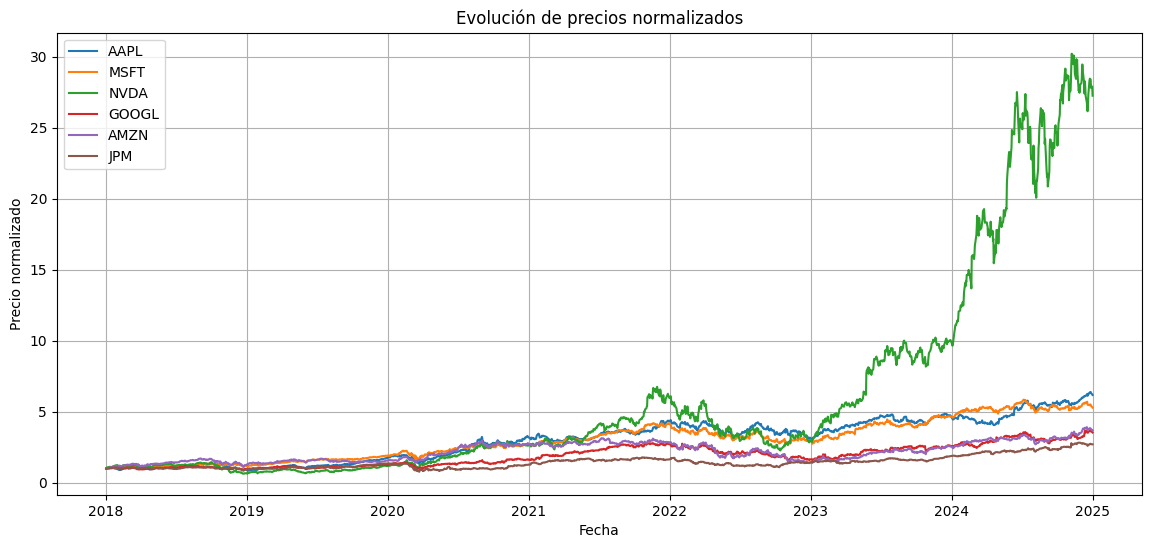

Matriz de correlación:


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA
Ticker,,,,,,
AAPL,1.000000,0.599180,0.642598,0.422163,0.729518,0.592651
AMZN,0.599180,1.000000,0.656491,0.300699,0.694741,0.585712
GOOGL,0.642598,0.656491,1.000000,0.421063,0.746716,0.589681
JPM,0.422163,0.300699,0.421063,1.000000,0.441103,0.348030
MSFT,0.729518,0.694741,0.746716,0.441103,1.000000,0.664927
NVDA,0.592651,0.585712,0.589681,0.348030,0.664927,1.000000


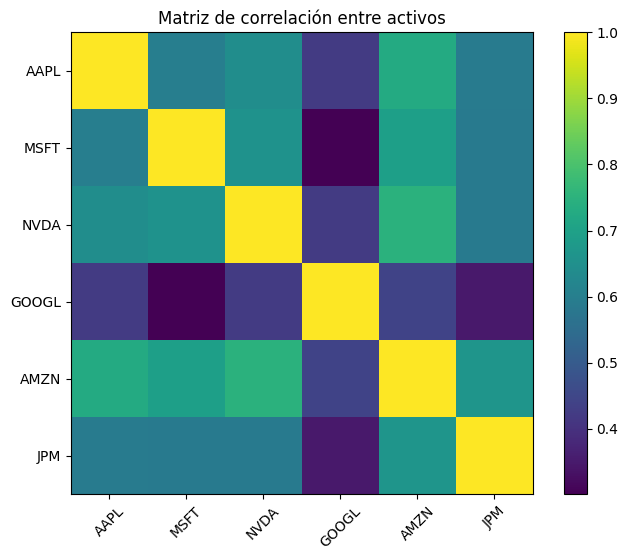

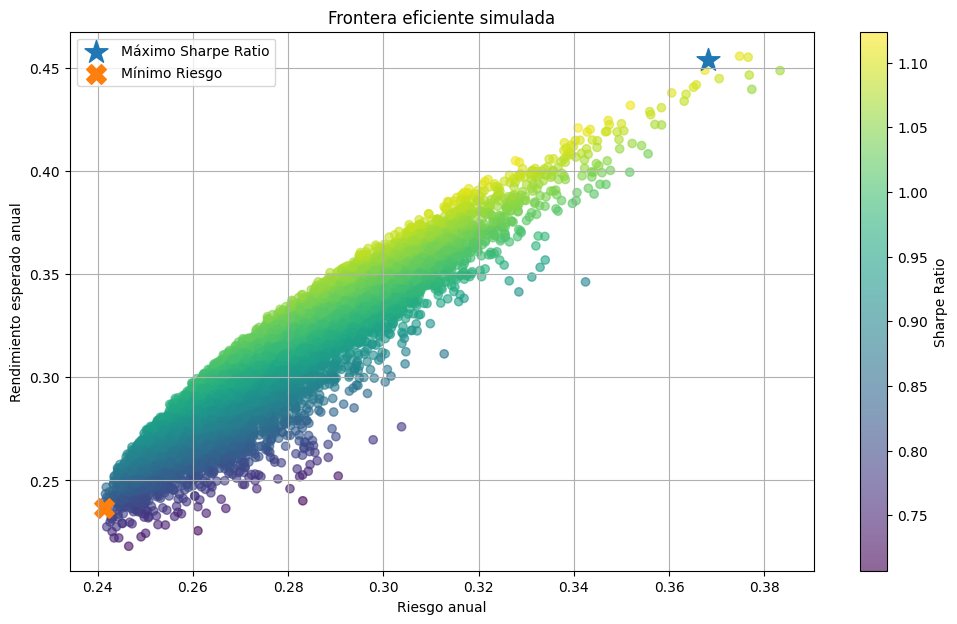

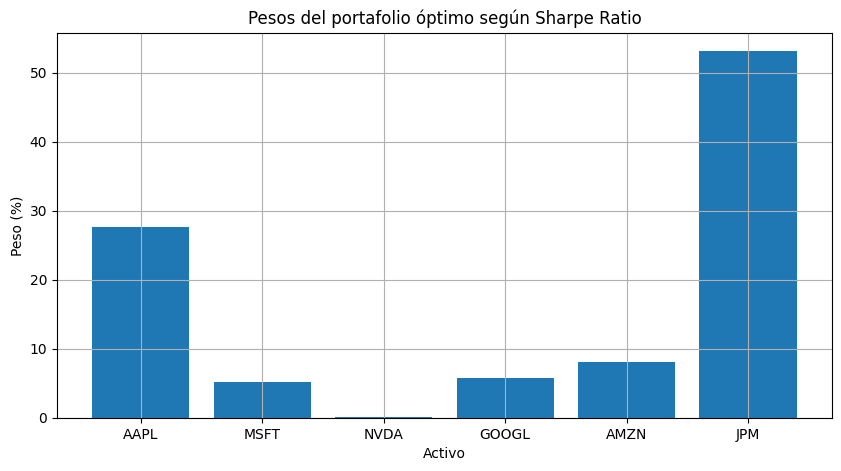

Comparación de portafolios:


,Portafolio,Rendimiento Esperado,Riesgo,Sharpe Ratio
0,Máximo Sharpe Ratio,0.453627,0.368054,1.123823
1,Mínimo Riesgo,0.236483,0.241295,0.814285


RESULTADO FINAL
El portafolio óptimo según el Sharpe Ratio asigna los siguientes pesos:
AAPL: 27.58%
MSFT: 5.25%
NVDA: 0.10%
GOOGL: 5.79%
AMZN: 8.15%
JPM: 53.14%
------------------------------------------
Rendimiento esperado anual: 45.36%
Riesgo anual: 36.81%
Sharpe Ratio: 1.1238


In [1]:
# ==========================================
# PROYECTO 2: Optimización de Portafolios
# Teoría Moderna de Portafolios de Markowitz
# Yahoo Finance + Python
# ==========================================

!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Parámetros principales
# ==========================================

tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "JPM"]

fecha_inicio = "2018-01-01"
fecha_fin = "2025-01-01"

numero_portafolios = 10000

tasa_libre_riesgo = 0.04   # 4% anual aproximado. Puedes cambiarlo.

# ==========================================
# 2. Descargar precios históricos
# ==========================================

datos = yf.download(
    tickers,
    start=fecha_inicio,
    end=fecha_fin,
    auto_adjust=True
)

precios = datos["Close"]

print("Precios históricos:")
display(precios.head())

# ==========================================
# 3. Calcular rendimientos diarios
# ==========================================

rendimientos_diarios = precios.pct_change().dropna()

print("Rendimientos diarios:")
display(rendimientos_diarios.head())

# ==========================================
# 4. Estadísticas anuales
# ==========================================

rendimiento_promedio_anual = rendimientos_diarios.mean() * 252
matriz_covarianza_anual = rendimientos_diarios.cov() * 252

print("Rendimiento promedio anual:")
display(rendimiento_promedio_anual)

print("Matriz de covarianza anual:")
display(matriz_covarianza_anual)

# ==========================================
# 5. Simulación Monte Carlo de portafolios
# ==========================================

resultados = np.zeros((3, numero_portafolios))
pesos_guardados = []

for i in range(numero_portafolios):

    pesos = np.random.random(len(tickers))
    pesos = pesos / np.sum(pesos)

    rendimiento_portafolio = np.sum(pesos * rendimiento_promedio_anual)

    riesgo_portafolio = np.sqrt(
        np.dot(pesos.T, np.dot(matriz_covarianza_anual, pesos))
    )

    sharpe_ratio = (rendimiento_portafolio - tasa_libre_riesgo) / riesgo_portafolio

    resultados[0, i] = rendimiento_portafolio
    resultados[1, i] = riesgo_portafolio
    resultados[2, i] = sharpe_ratio

    pesos_guardados.append(pesos)

resultados_df = pd.DataFrame({
    "Rendimiento": resultados[0],
    "Riesgo": resultados[1],
    "Sharpe Ratio": resultados[2]
})

# ==========================================
# 6. Portafolio con mayor Sharpe Ratio
# ==========================================

indice_max_sharpe = resultados_df["Sharpe Ratio"].idxmax()
mejor_peso_sharpe = pesos_guardados[indice_max_sharpe]

portafolio_sharpe = pd.DataFrame({
    "Activo": tickers,
    "Peso": mejor_peso_sharpe
})

portafolio_sharpe["Peso (%)"] = portafolio_sharpe["Peso"] * 100

print("Portafolio óptimo según máximo Sharpe Ratio:")
display(portafolio_sharpe)

print("Rendimiento esperado anual:")
print(f"{resultados_df.loc[indice_max_sharpe, 'Rendimiento']:.2%}")

print("Riesgo anual:")
print(f"{resultados_df.loc[indice_max_sharpe, 'Riesgo']:.2%}")

print("Sharpe Ratio:")
print(f"{resultados_df.loc[indice_max_sharpe, 'Sharpe Ratio']:.4f}")

# ==========================================
# 7. Portafolio de mínimo riesgo
# ==========================================

indice_min_riesgo = resultados_df["Riesgo"].idxmin()
mejor_peso_riesgo = pesos_guardados[indice_min_riesgo]

portafolio_min_riesgo = pd.DataFrame({
    "Activo": tickers,
    "Peso": mejor_peso_riesgo
})

portafolio_min_riesgo["Peso (%)"] = portafolio_min_riesgo["Peso"] * 100

print("Portafolio de mínimo riesgo:")
display(portafolio_min_riesgo)

print("Rendimiento esperado anual:")
print(f"{resultados_df.loc[indice_min_riesgo, 'Rendimiento']:.2%}")

print("Riesgo anual:")
print(f"{resultados_df.loc[indice_min_riesgo, 'Riesgo']:.2%}")

print("Sharpe Ratio:")
print(f"{resultados_df.loc[indice_min_riesgo, 'Sharpe Ratio']:.4f}")

# ==========================================
# 8. Gráfica de precios normalizados
# ==========================================

precios_normalizados = precios / precios.iloc[0]

plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(precios_normalizados.index, precios_normalizados[ticker], label=ticker)

plt.title("Evolución de precios normalizados")
plt.xlabel("Fecha")
plt.ylabel("Precio normalizado")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 9. Matriz de correlación
# ==========================================

correlacion = rendimientos_diarios.corr()

print("Matriz de correlación:")
display(correlacion)

plt.figure(figsize=(8, 6))
plt.imshow(correlacion, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(tickers)), tickers, rotation=45)
plt.yticks(range(len(tickers)), tickers)
plt.title("Matriz de correlación entre activos")
plt.show()

# ==========================================
# 10. Frontera eficiente simulada
# ==========================================

plt.figure(figsize=(12, 7))
plt.scatter(
    resultados_df["Riesgo"],
    resultados_df["Rendimiento"],
    c=resultados_df["Sharpe Ratio"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    resultados_df.loc[indice_max_sharpe, "Riesgo"],
    resultados_df.loc[indice_max_sharpe, "Rendimiento"],
    marker="*",
    s=300,
    label="Máximo Sharpe Ratio"
)

plt.scatter(
    resultados_df.loc[indice_min_riesgo, "Riesgo"],
    resultados_df.loc[indice_min_riesgo, "Rendimiento"],
    marker="X",
    s=200,
    label="Mínimo Riesgo"
)

plt.title("Frontera eficiente simulada")
plt.xlabel("Riesgo anual")
plt.ylabel("Rendimiento esperado anual")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 11. Gráfica de pesos del portafolio óptimo
# ==========================================

plt.figure(figsize=(10, 5))
plt.bar(portafolio_sharpe["Activo"], portafolio_sharpe["Peso (%)"])
plt.title("Pesos del portafolio óptimo según Sharpe Ratio")
plt.xlabel("Activo")
plt.ylabel("Peso (%)")
plt.grid(True)
plt.show()

# ==========================================
# 12. Comparación entre portafolios
# ==========================================

comparacion = pd.DataFrame({
    "Portafolio": ["Máximo Sharpe Ratio", "Mínimo Riesgo"],
    "Rendimiento Esperado": [
        resultados_df.loc[indice_max_sharpe, "Rendimiento"],
        resultados_df.loc[indice_min_riesgo, "Rendimiento"]
    ],
    "Riesgo": [
        resultados_df.loc[indice_max_sharpe, "Riesgo"],
        resultados_df.loc[indice_min_riesgo, "Riesgo"]
    ],
    "Sharpe Ratio": [
        resultados_df.loc[indice_max_sharpe, "Sharpe Ratio"],
        resultados_df.loc[indice_min_riesgo, "Sharpe Ratio"]
    ]
})

print("Comparación de portafolios:")
display(comparacion)

# ==========================================
# 13. Interpretación final
# ==========================================

print("==========================================")
print("RESULTADO FINAL")
print("==========================================")
print("El portafolio óptimo según el Sharpe Ratio asigna los siguientes pesos:")

for i in range(len(tickers)):
    print(f"{tickers[i]}: {mejor_peso_sharpe[i]*100:.2f}%")

print("------------------------------------------")
print(f"Rendimiento esperado anual: {resultados_df.loc[indice_max_sharpe, 'Rendimiento']:.2%}")
print(f"Riesgo anual: {resultados_df.loc[indice_max_sharpe, 'Riesgo']:.2%}")
print(f"Sharpe Ratio: {resultados_df.loc[indice_max_sharpe, 'Sharpe Ratio']:.4f}")